# Log Regression

In [45]:
import numpy as np
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([0, 0, 0, 1, 1, 1])

In [46]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [49]:
epoch = 10000
w = 0
b = 0
alp = 0.01
for i in range(epoch):
  y_pred = sigmoid(w * x + b)
  derL_w = np.mean((y_pred- y)*x)
  derL_b = np.mean(y_pred- y)
  w = w - alp * derL_w
  b = b - alp * derL_b
  loss = -np.mean(y * np.log(y_pred) +(1 - y) * np.log(1 - y_pred))
  if i % 1000 == 0:
    print(i, loss)

0 0.6931471805599453
1000 0.4215099262582307
2000 0.32546981951314674
3000 0.27160641246477796
4000 0.2371210212248502
5000 0.21293813496191746
6000 0.19486907571522596
7000 0.18073453164219178
8000 0.1692913705565187
9000 0.15977816548374782


In [54]:
y_prob = sigmoid(w * x + b)

y_pred = (y_prob >= 0.5).astype(int)

accuracy = np.mean(y_pred == y)

print("Probabilities:", y_prob)
print("Predictions:", y_pred)
print("Accuracy:", accuracy)

Probabilities: [0.01825154 0.09261762 0.35914361 0.75471481 0.9441133  0.98933348]
Predictions: [0 0 0 1 1 1]
Accuracy: 1.0


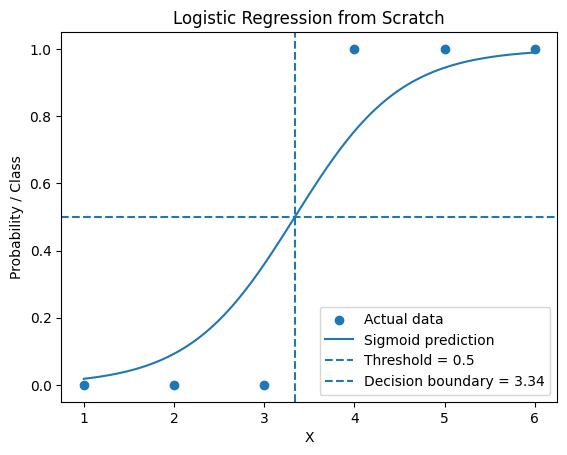

In [55]:
import matplotlib.pyplot as plt

# Generate smooth x values for the sigmoid curve
x_plot = np.linspace(x.min(), x.max(), 200)

# Predicted probability for each x
y_prob_plot = sigmoid(w * x_plot + b)

# Decision boundary
decision_boundary = -b / w

plt.scatter(x, y, label="Actual data")
plt.plot(x_plot, y_prob_plot, label="Sigmoid prediction")
plt.axhline(0.5, linestyle="--", label="Threshold = 0.5")
plt.axvline(
    decision_boundary,
    linestyle="--",
    label=f"Decision boundary = {decision_boundary:.2f}"
)

plt.xlabel("X")
plt.ylabel("Probability / Class")
plt.title("Logistic Regression from Scratch")
plt.legend()
plt.show()